# Research Notebook
## Caleb Miller
## Date: Jan. 12 - 19, 2026

# 1: Experience
## Research activities this week

Wrote Python code to fit X-ray gas temperature profiles in galaxy groups using analytic models from the literature.

Implemented and tested multiple temperature parameterizations from Gastaldello et al. (2007).

Fit Chandra and XMM temperature data simultaneously for the galaxy group MKW4.

Attended research group meetings to discuss model choices and fitting strategy.

## Motivation

The goal of this project is to model the hot gas and the underlying dark matter distribution under the assumption of hydrostatic equilibrium, using X-ray observations to constrain the mass profile. In previous discussions, we identified that a accurate gas temperature profile is a critical prerequisite to solving the equation for hydrostatic equilibrium. This week, I focused on learning how different analytic temperature models behave and how well they match the the real X-ray observations, so that we can later propagate these fits into the hydrostatic equilibrium equation.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

## Temperature Profile Modeling

In this work, I modeled the radial gas temperature profile $T_{\mathrm{gas}}(r)$ using analytic parameterizations from Gastaldello et al. (2007), which are designed to capture the observed rise and fall of the gas temperature.

I wrote Python code to load the MKW4 temperature data from an Excel spreadsheet, compute the central radius of each annulus $(R=(R_1+R_2)/2)$ and its radial uncertainty $(\Delta R=(R_2-R_1)/2)$, implement the **Gastaldello et al.** temperature models (Eq. 4, Eq. 5, Eq. 6), and fit the model parameters using `scipy.optimize.curve_fit`. Finally, I plotted the best-fit temperature curve on top of the data (with error bars) to visually assess the fit quality.


## Analytic Temperature Models

There are three models in the **Gastaldello et al.** paper that I used to fit temperature and radius data:

### Equation (4)

$$
T(r) =
\left[
\left(\frac{1}{t_1(r)}\right)^s
+
\left(\frac{1}{t_2(r)}\right)^s
\right]^{-1/s}.
$$

The two components are defined as

$$
t_1(r) = T_{1,100}\left(\frac{r}{100,\mathrm{kpc}}\right)^{p_1},
$$

$$
t_2(r) = T_{2,100}\left(\frac{r}{100,\mathrm{kpc}}\right)^{p_2}.
$$

---

### Equation (5)

$$
T(r) = T_0
+ t_1(r), e^{-(r/r_p)^\gamma}
+ t_2(r), \left[1 - e^{-(r/r_p)^\gamma}\right].
$$

The two components are defined as

$$
t_1(r) = T_1\left(\frac{r}{r_0}\right)^{p_1},
$$

$$
t_2(r) = T_2\left(\frac{r}{r_0}\right)^{p_2}.
$$

---

### Equation (6)

$$
T(r) = t_1(r), e^{-(r/r_p)^\gamma}
+ t_2(r), \left[1 - e^{-(r/r_p)^\gamma}\right].
$$

The inner and outer components are defined as

$$
t_1(r) = a + T_1 \frac{(r/r_1)^{p_1}}{1 + (r/r_1)^{p_1}},
$$

$$
t_2(r) = b + T_2 \frac{1}{1 + (r/r_2)^{p_2}}.
$$

---

Here, the radius r is fixed by the observational data. All remaining quantities appearing in the models — a, b, T1, T2, r1, r2, p1, p2, rp, and γ — are treated as free parameters and are determined by fitting the model to the X-ray temperature data

# Code used for plots and fitting
This code loads X-ray temperature data for the galaxy group MKW4 from Chandra and XMM observations and computes a mean radius and uncertainty for each radial annulus. It implements temperature models from Gastaldello et al. (Eq. 4, Eq. 5, and Eq. 6) and fits their free parameters by `scipy.optimize.curve_fit` to the combined Chandra and XMM data. The code then evaluates the best-fit temperature profile over the radial range of the data and produces plots comparing the model to the observed temperatures with error bars.
```
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

SYSTEM = "mkw4"
FILE = "Xray elliptical data.xlsx"

data = pd.read_excel(FILE, sheet_name=SYSTEM)

data["R (kpc)"] = 0.5 * (data["R1 (kpc)"] + data["R2 (kpc)"])
data["Error R (kpc)"] = 0.5 * (data["R2 (kpc)"] - data["R1 (kpc)"])

chandra_data = data[data["Source"] == "Chandra"]
xmm_data     = data[data["Source"] == "XMM"]

def T_eq4(r, T1_100, p1, T2_100, p2, s):
    r = np.asarray(r, float)
    r = np.clip(r, 1e-6, None)
    t1 = T1_100 * (r / 100.0) ** p1
    t2 = T2_100 * (r / 100.0) ** p2
    return ((1.0 / t1) ** s + (1.0 / t2) ** s) ** (-1.0 / s)

r_all  = np.concatenate([chandra_data["R (kpc)"].to_numpy(float),
                         xmm_data["R (kpc)"].to_numpy(float)])
T_all  = np.concatenate([chandra_data["Temp (keV)"].to_numpy(float),
                         xmm_data["Temp (keV)"].to_numpy(float)])
eT_all = np.concatenate([chandra_data["Error Temp (keV)"].to_numpy(float),
                         xmm_data["Error Temp (keV)"].to_numpy(float)])

p0 = [np.median(T_all), 0.0, np.median(T_all), -0.2, 2.0]   # [T1_100, p1, T2_100, p2, s]
bounds = ([0.0, -3.0, 0.0, -3.0, 0.1],
          [10.0,  3.0, 10.0,  3.0, 20.0])

popt, pcov = curve_fit(
    T_eq4, r_all, T_all,
    sigma=eT_all,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=200000
)

r_fit = np.linspace(r_all.min()*0.8, r_all.max()*1.1, 500)
T_fit = T_eq4(r_fit, *popt)

plt.figure()

plt.errorbar(
    chandra_data["R (kpc)"], chandra_data["Temp (keV)"],
    xerr=chandra_data["Error R (kpc)"], yerr=chandra_data["Error Temp (keV)"],
    fmt="o", label="Chandra"
)
plt.errorbar(
    xmm_data["R (kpc)"], xmm_data["Temp (keV)"],
    xerr=xmm_data["Error R (kpc)"], yerr=xmm_data["Error Temp (keV)"],
    fmt="o", label="XMM"
)

plt.plot(r_fit, T_fit, label="Best-fit Gastaldello Eq. (4)")

plt.xlabel("R (kpc)")
plt.ylabel("Temp (keV)")
plt.title(f"{SYSTEM}: Temperature fit (Eq. 4)")
plt.legend()
plt.grid(True)
plt.show()

labels = ["T1_100", "p1", "T2_100", "p2", "s"]
print("\nBest-fit parameters:")
for name, val in zip(labels, popt):
    print(f"{name:6s} = {val:.5g}")
```
(This is specifically the code for the Eq. 4 model, but the models for Eq. 5 and 6 are virtually the same. The the equations and input parameters are the only thing that changes between the code.)

# 3: So what? (What does it mean?)
## Describe your results
| Equation 4 model | Equation 5 model | Equation 6 model |
|---------|----------|----------|
| 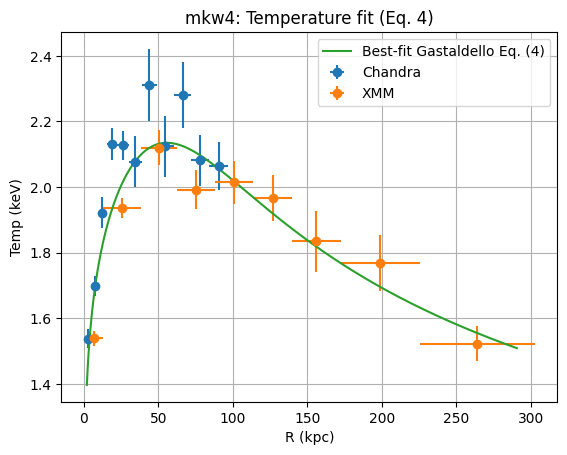 | 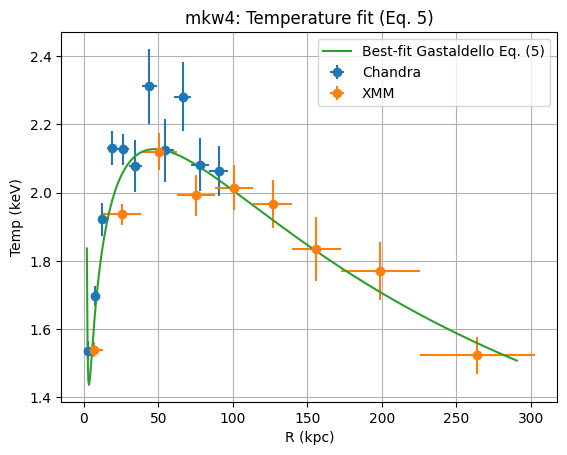 | 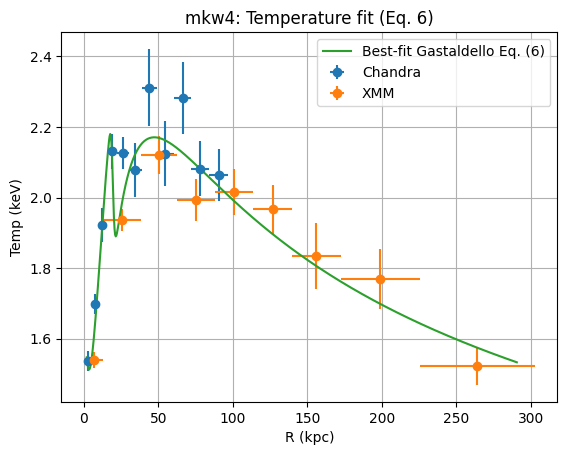 |

*Figure 1: Best-fit gas temperature profile for MKW4 using the Gastaldello et al. (2007) equations 4, 5, and 6, compared with Chandra and XMM temperature measurements.*

This week’s main result was the successful implementation and comparison of three parametric temperature models (Gastaldello et al. Equations 4, 5, and 6) fitted to the Chandra and XMM X-ray temperature data for the MKW 4 galaxy group, shown in figure 1. All three models were able to reproduce the overall qualitative behaviour of the observed temperature profile: a rapid rise in temperature at small radii, a peak near r~40−60kpc, and a gradual decline at larger radii.

Equation 4, which uses a smooth broken power-law transition, provides the most stable and well-behaved fit across the full radial range. The model captures both the inner temperature rise and the outer decline without introducing unphysical oscillations, making it a strong baseline model for subsequent mass reconstruction. Equation 5 introduces an exponential transition scale rp, which allows for more flexibility in how the inner and outer temperature components are weighted. While this model still follows the data reasonably well, it shows some sensitivity at small radii where the exponential term changes rapidly causing a sharp increase in temperature. Equation 6 adds further freedom by allowing the inner and outer temperature components to asymptote smoothly using rational functions. Although this model can match the data, the resulting fit shows noticeable sensitivity near r~25kpc, where the fit temperature rapidly increases, decreases, and then increases again.

Overall, this activity was important for the progress of the project because the temperature profile enters directly into the hydrostatic equilibrium equation used to infer the total gravitating mass. These results were a success in the sense that all three models could be implemented, fitted, and visually compared, in order to find the best model for the data set. A stable, differentiable temperature model is essential for computing reliable mass profiles, especially when combining temperature gradients with gas density measurements. From this comparison, Equation 4 appears best suited for initial mass modeling, while Equations 5 and 6 may be useful for testing systematic uncertainties.

# 4. Now what? (What's next?)
## Plan for the next week



I will extend this analysis to a larger sample of galaxy groups by modeling their temperature profiles using the same methodology applied to the MKW4 system. For each galaxy group, I will fit the three analytic temperature parameterizations (Equations 4–6) and quantitatively compare their performance by computing a chi-squared statistic,
$$
\chi^2 = \sum_i \left(\frac{T_{\rm data}(r_i) - T_{\rm model}(r_i)}{\sigma_{T,i}}\right)^2,
$$
This comparison will allow me to systematically assess which temperature model provides the best description of the data. 

# 5. Bibliography

[1] M. Gastaldello et al., Temperature, entropy and mass profiles of nearby galaxy groups observed with Chandra and XMM-Newton, Astrophys. J. 669, 158 (2007), arXiv:astro-ph/0610134.

| Category       | Points      |
| ------------- |:------------:|
| Formatting    |       1 / 2       |
| Experience    |       2 / 2       |
| What?         |       2 / 2       |
| So what?      |       4 / 4       |
| Now what?     |       4 / 4       |
| Bibliography  |       3 / 3     |
| Style         |       3 / 3       |
| Total         |       19 / 20   |